In [1]:
import subprocess
subprocess.run(["pip","install","pandas","numpy","matplotlib","scikit-learn"])

CompletedProcess(args=['pip', 'install', 'pandas', 'numpy', 'matplotlib', 'scikit-learn'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(
    'Steel_industry_data.csv',
    sep=';',
    na_values=['?'],
    low_memory=False
)

# Quick look
print(df.shape)
print(df.head())
print(df.dtypes)


(35040, 1)
  date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0  01/01/2018 00:15,3.17,2.95,0,0,73.21,100,900,W...                                                                                                                                               
1  01/01/2018 00:30,4,4.46,0,0,66.77,100,1800,Wee...                                                                                                                                               
2  01/01/2018 00:45,3.24,3.28,0,0,70.28,100,2700,...                                                                                                                                               
3  01/01/2018 01:00,3.31,3.56,0,0,68.09,100,3600,...                                                                                                                                               
4  01/01/

In [3]:
df = pd.read_csv(
    'Steel_industry_data.csv',
    sep=',',
    low_memory=False
)

print(df.shape)
print(df.head())
print(df.dtypes)

(35040, 11)
               date  Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0  01/01/2018 00:15       3.17                                  2.95   
1  01/01/2018 00:30       4.00                                  4.46   
2  01/01/2018 00:45       3.24                                  3.28   
3  01/01/2018 01:00       3.31                                  3.56   
4  01/01/2018 01:15       3.82                                  4.50   

   Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                   0.0        0.0   
1                                   0.0        0.0   
2                                   0.0        0.0   
3                                   0.0        0.0   
4                                   0.0        0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         73.21                         100.0   900   
1                         66.77                         100.0  1800   
2                

In [5]:
# Combine Date and Time into a single datetime column
df['datetime'] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M')

# Set it as the index
df = df.set_index('datetime')

# Drop the now-redundant columns
df = df.drop(columns=['date'])

# Check missing values
print(df.isnull().sum())
print(f"\nTotal rows: {len(df)}")

Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

Total rows: 35040


In [7]:
print("\nUsage_kWh:")
print(df['Usage_kWh'].describe())


Usage_kWh:
count    35040.000000
mean        27.386892
std         33.444380
min          0.000000
25%          3.200000
50%          4.570000
75%         51.237500
max        157.180000
Name: Usage_kWh, dtype: float64


In [8]:
# Resample from per-minute to per-hour (mean)
df_hourly = df['Usage_kWh'].resample('h').mean()
df_hourly = df_hourly.to_frame()

print(df_hourly.shape)
print(df_hourly.head())

(8760, 1)
                     Usage_kWh
datetime                      
2018-01-01 00:00:00     3.4575
2018-01-01 01:00:00     3.5025
2018-01-01 02:00:00     3.5300
2018-01-01 03:00:00     3.4550
2018-01-01 04:00:00     3.6175


In [9]:
# Extract time features
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek
df_hourly['month'] = df_hourly.index.month
df_hourly['is_weekend'] = df_hourly['day_of_week'].isin([5, 6]).astype(int)

# Add lag features
df_hourly['lag_1h'] = df_hourly['Usage_kWh'].shift(1)
df_hourly['lag_24h'] = df_hourly['Usage_kWh'].shift(24)
df_hourly['lag_168h'] = df_hourly['Usage_kWh'].shift(168)

# Drop nulls created by lag
df_hourly = df_hourly.dropna()

print(df_hourly.shape)
print(df_hourly.head())

(8592, 8)
                     Usage_kWh  hour  day_of_week  month  is_weekend  lag_1h  \
datetime                                                                       
2018-01-08 00:00:00     3.7875     0            0      1           0  3.4850   
2018-01-08 01:00:00     3.6375     1            0      1           0  3.7875   
2018-01-08 02:00:00     3.5000     2            0      1           0  3.6375   
2018-01-08 03:00:00     3.5900     3            0      1           0  3.5000   
2018-01-08 04:00:00     3.5825     4            0      1           0  3.5900   

                     lag_24h  lag_168h  
datetime                                
2018-01-08 00:00:00   3.3850    3.4575  
2018-01-08 01:00:00   3.3900    3.5025  
2018-01-08 02:00:00   3.5450    3.5300  
2018-01-08 03:00:00   3.4225    3.4550  
2018-01-08 04:00:00   3.5100    3.6175  


In [10]:
# Define features and target
X = df_hourly[['hour', 'day_of_week', 'month', 'is_weekend', 'lag_1h', 'lag_24h', 'lag_168h']]
y = df_hourly['Usage_kWh']

# Split by time - first 80% for training, last 20% for testing
split_index = int(len(df_hourly) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")
print(f"Training ends: {X_train.index[-1]}")
print(f"Testing starts: {X_test.index[0]}")

Training rows: 6873
Testing rows: 1719
Training ends: 2018-10-21 08:00:00
Testing starts: 2018-10-21 09:00:00


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.3f} kW")

# Baseline comparison - what if we just predicted the mean?
baseline_mae = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))
print(f"Baseline MAE (always predict mean): {baseline_mae:.3f} kW")
print(f"Improvement over baseline: {((baseline_mae - mae) / baseline_mae * 100):.1f}%")


Mean Absolute Error: 5.568 kW
Baseline MAE (always predict mean): 26.469 kW
Improvement over baseline: 79.0%


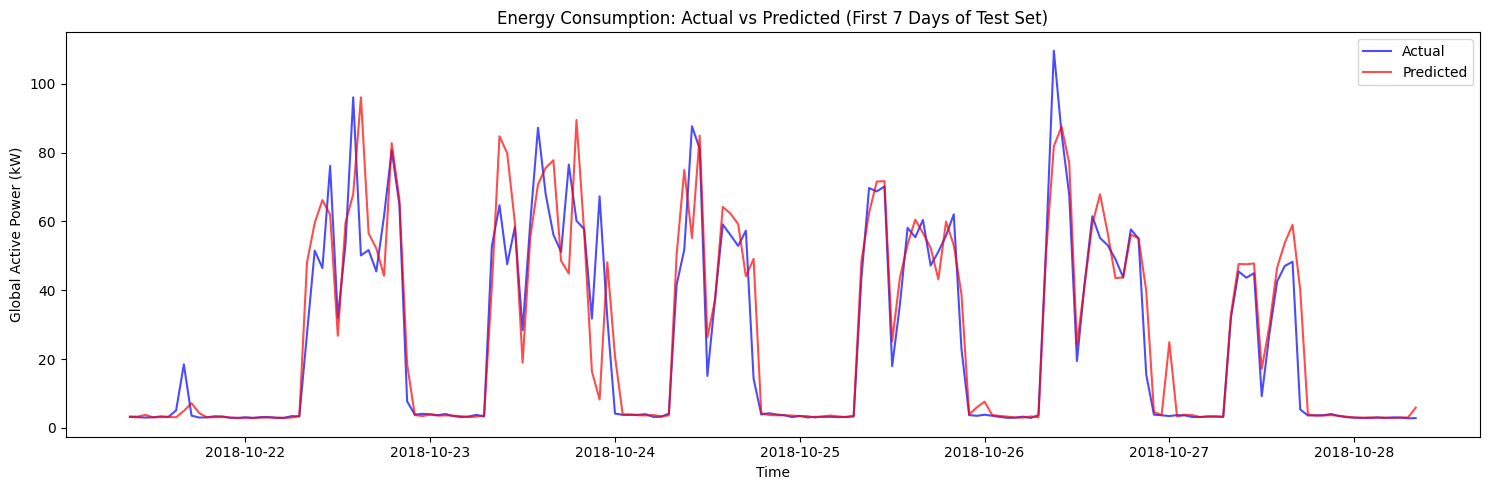

In [12]:
import matplotlib.pyplot as plt

# Plot predictions vs actual for first 7 days of test set
plt.figure(figsize=(15, 5))
plt.plot(y_test.index[:168], y_test.values[:168], label='Actual', color='blue', alpha=0.7)
plt.plot(y_test.index[:168], y_pred[:168], label='Predicted', color='red', alpha=0.7)
plt.title('Energy Consumption: Actual vs Predicted (First 7 Days of Test Set)')
plt.xlabel('Time')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.tight_layout()
plt.show()


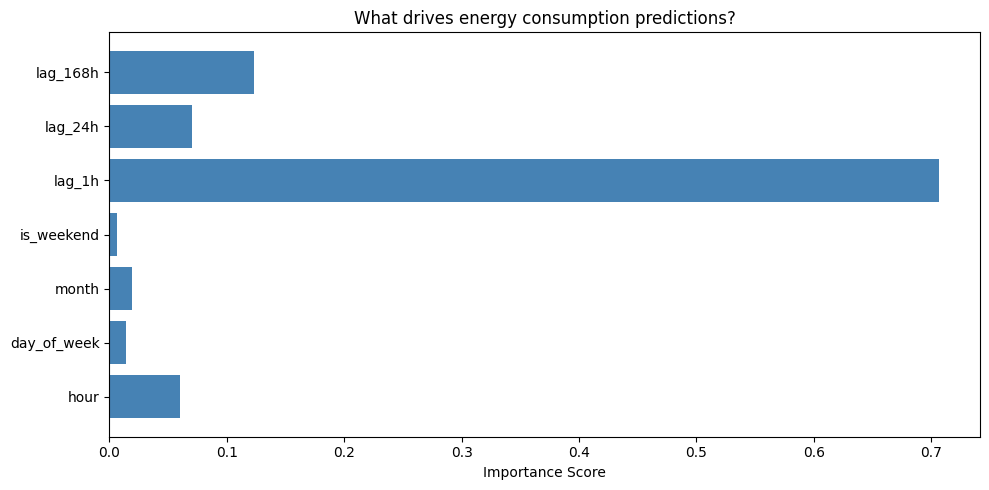

lag_1h: 0.706
lag_168h: 0.123
lag_24h: 0.070
hour: 0.060
month: 0.019
day_of_week: 0.014
is_weekend: 0.007


In [13]:
# Feature importance
features = ['hour', 'day_of_week', 'month', 'is_weekend', 'lag_1h', 'lag_24h', 'lag_168h']
importances = model.feature_importances_

plt.figure(figsize=(10, 5))
plt.barh(features, importances, color='steelblue')
plt.xlabel('Importance Score')
plt.title('What drives energy consumption predictions?')
plt.tight_layout()
plt.show()

# Print the values too
for feature, importance in sorted(zip(features, importances), key=lambda x: x[1], reverse=True):
    print(f"{feature}: {importance:.3f}")